<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/pytorch_recap/01_pytorch_getting_started.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### tensors

In [ ]:
import torch

# 스칼라 텐서 만들기
x = torch.tensor(5)
print(x)
print(x.dim()) # 텐서의 차원 확인

tensor(5)
0


In [ ]:
x = torch.tensor([[1., 2.], [3., 4.]]) # 부동 소수점 텐서 생성

print(x.dtype) # 텐서의 자료형 (torch.float32)
print(x.shape) # 텐서의 크기 (torch.Size([2, 2]))
print(x.device) # 텐서가 위치한 장치 (CPU 또는 GPU)


torch.float32
torch.Size([2, 2])
cpu


In [ ]:
# 크기가 3x2이고 모든 원소가 1인 텐서 만들기
ones_tensor = torch.ones(3, 2)
print(ones_tensor)


tensor([[1., 1.],
        [1., 1.],
        [1., 1.]])


In [ ]:
# 크기가 2x3이고 모든 원소가 0인 텐서 만들기
zeros_tensor = torch.zeros(2, 3)
print(zeros_tensor)

tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [ ]:
# 1차원 텐서(벡터) 만들기
x = torch.tensor([1, 2, 3])
print(x)
print(x.dim())


tensor([1, 2, 3])
1


In [ ]:
# 2차원 텐서(행렬) 만들기
x = torch.tensor([[1, 2], [3, 4]])
print(x)
print(x.dim())


tensor([[1, 2],
        [3, 4]])
2


### rank

In [ ]:
first_col = x[:, 0]
second_col = x[:, 1]

# 첫 번째와 두 번째 열의 선형결합으로 새로운 변수 3개 생성
new_var1 = first_col + second_col
new_var2 = 2 * first_col - second_col
new_var3 = 0.5 * first_col + 1.5 * second_col

# 새로운 변수들을 열 벡터 형태로 변환
new_var1 = new_var1.unsqueeze(1)
new_var2 = new_var2.unsqueeze(1)
new_var3 = new_var3.unsqueeze(1)

# 기존 x에 새로운 변수들을 추가 (열 방향으로 연결)
x_updated = torch.cat((x, new_var1, new_var2, new_var3), dim=1)

print(x_updated)
print(x.dim())

tensor([[1.0000, 2.0000, 3.0000, 0.0000, 3.5000],
        [3.0000, 4.0000, 7.0000, 2.0000, 7.5000]])
2


In [ ]:
# 크기가 3x3이고 모든 대각 원소가 1인 텐서 만들기
eye_tensor = torch.eye(3)
print(eye_tensor)

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])


In [ ]:
first_col = eye_tensor[:, 0]
second_col = eye_tensor[:, 1]
third_col = eye_tensor[:, 2]

# first_col과 second_col의 내적은 스칼라(0차원 텐서)가 됩니다.
dot_product_result = first_col @ second_col
print(dot_product_result)

tensor(0.)


### matrix, vector operations

In [ ]:
x = torch.tensor([[1, 2], [3, 4]])
y = torch.tensor([[5, 6], [7, 8]])

# 덧셈
print(x + y)
print(torch.add(x, y))

# 곱셈 (원소별 곱셈)
print(x * y)
print(torch.mul(x, y))


tensor([[ 6,  8],
        [10, 12]])
tensor([[ 6,  8],
        [10, 12]])
tensor([[ 5, 12],
        [21, 32]])
tensor([[ 5, 12],
        [21, 32]])


In [ ]:
# 행렬 곱셈
A = torch.tensor([[1, 2], [3, 4]])
B = torch.tensor([[5, 6], [7, 8]])

# 행렬 A와 B의 곱
C = torch.matmul(A, B)
print(C)

# 또는 '@' 연산자 사용
D = A @ B
print(D)


tensor([[19, 22],
        [43, 50]])
tensor([[19, 22],
        [43, 50]])


In [ ]:
x = torch.tensor([[1, 2], [3, 4]])
scalar = 10

# 브로드캐스팅 예시: x의 모든 원소에 10을 더하기
result = x + scalar
print(result)


tensor([[11, 12],
        [13, 14]])


In [ ]:
x = torch.tensor([[10, 20, 30],
                  [40, 50, 60],
                  [70, 80, 90]])

# 특정 원소 접근 (두 번째 행, 세 번째 열)
print(x[1, 2])

# 슬라이싱 (첫 번째 행의 모든 원소)
print(x[0, :])

# 슬라이싱 (두 번째 열의 모든 원소)
print(x[:, 1])

# 여러 행, 여러 열 가져오기
print(x[0:2, 1:]) # 첫 번째, 두 번째 행 & 두 번째, 세 번째 열


tensor(60)
tensor([10, 20, 30])
tensor([20, 50, 80])
tensor([[20, 30],
        [50, 60]])


### probability distribution

In [ ]:
# 0과 1 사이의 균등 분포를 갖는 랜덤 텐서 만들기
random_tensor = torch.rand(2, 2)
print(random_tensor)


tensor([[0.4804, 0.8556],
        [0.7639, 0.1229]])


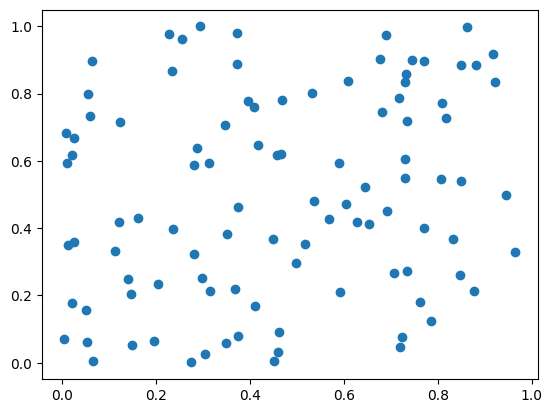

In [ ]:
random_tensor = torch.rand(100, 2)

import matplotlib.pyplot as plt
plt.scatter(random_tensor[:, 0], random_tensor[:, 1])
plt.show()

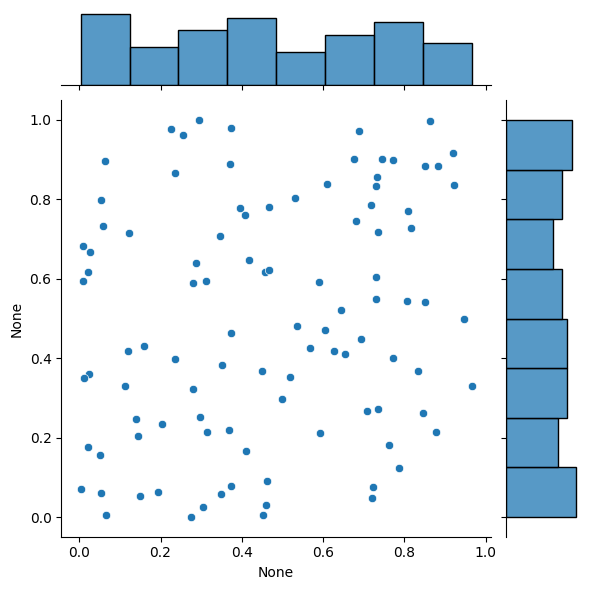

In [ ]:
# seaborn joint plot
import seaborn as sns
sns.jointplot(x=random_tensor[:, 0], y=random_tensor[:, 1])
plt.show()

In [ ]:
# 표준 정규 분포를 따르는 2x2 텐서 만들기
normal_tensor = torch.randn(2, 2)
print(normal_tensor)

tensor([[-1.1262,  2.5164],
        [-0.6675, -0.2967]])


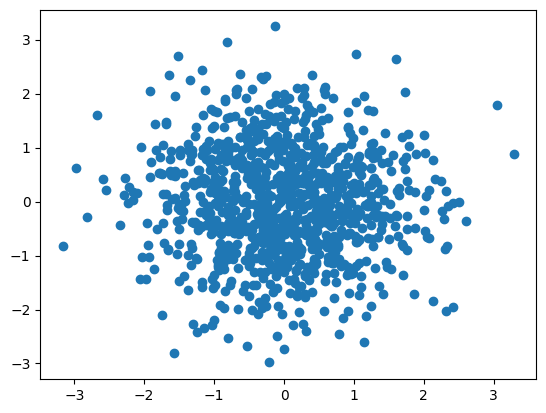

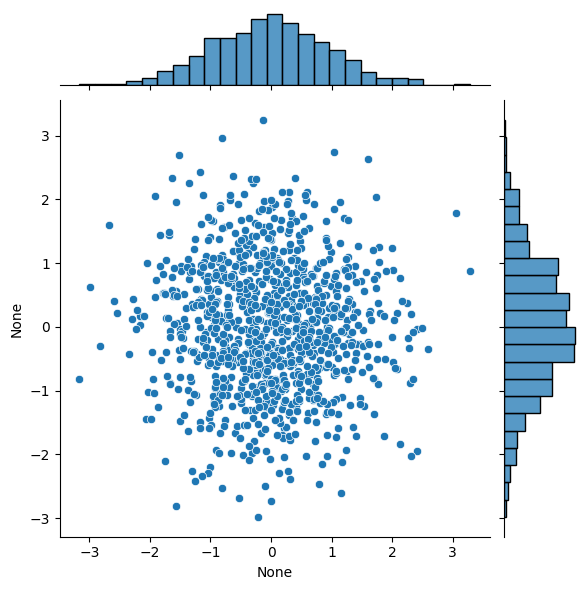

In [ ]:
normal_tensor = torch.randn(1000, 2)
# 시각화
plt.scatter(normal_tensor[:, 0], normal_tensor[:, 1])
plt.show()

# seaborn joint plot
import seaborn as sns
sns.jointplot(x=normal_tensor[:, 0], y=normal_tensor[:, 1])
plt.show()

### Regression
- x의 차원(x_dim)을 변경하면서 실습

In [ ]:
import torch

x_dim  = 10

# 1. 데이터 생성
X = torch.randn(1000, x_dim)
true_w, true_b = 3.0, 2.0
y = X * true_w + true_b + torch.randn(1000, x_dim) * 0.3  # 노이즈 추가

# 2. 가중치(w)와 편향(b) 초기화 (학습 대상)
w = torch.randn(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

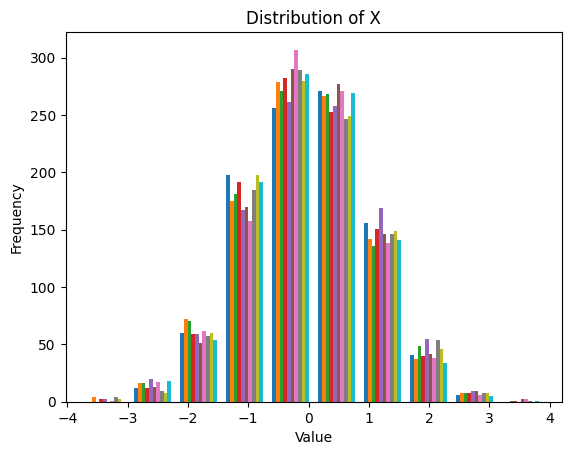

In [ ]:
plt.hist(X.squeeze().numpy())
plt.title('Distribution of X')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [ ]:
learning_rate = 0.01
epochs = 500

for epoch in range(epochs):
    # 3. 예측값 계산 (Forward Pass)
    prediction = X * w + b

    # 4. 손실 함수 계산 (Mean Squared Error)
    loss = torch.mean((prediction - y) ** 2)

    # 5. 역전파 (Backward Pass)
    # loss로부터 w와 b의 기울기를 계산합니다.
    loss.backward()

    # 6. 파라미터 업데이트 및 기울기 초기화
    with torch.no_grad():
        w -= w.grad * learning_rate
        b -= b.grad * learning_rate

        # 중요: 다음 루프를 위해 기울기를 0으로 초기화해야 합니다.
        w.grad.zero_()
        b.grad.zero_()

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}: Loss = {loss.item():.4f}, w = {w.item():.4f}, b = {b.item():.4f}")

Epoch 100: Loss = 0.3215, w = 2.6182, b = 1.7266
Epoch 200: Loss = 0.0932, w = 2.9518, b = 1.9655
Epoch 300: Loss = 0.0891, w = 2.9957, b = 1.9985
Epoch 400: Loss = 0.0890, w = 3.0015, b = 2.0031
Epoch 500: Loss = 0.0890, w = 3.0023, b = 2.0037


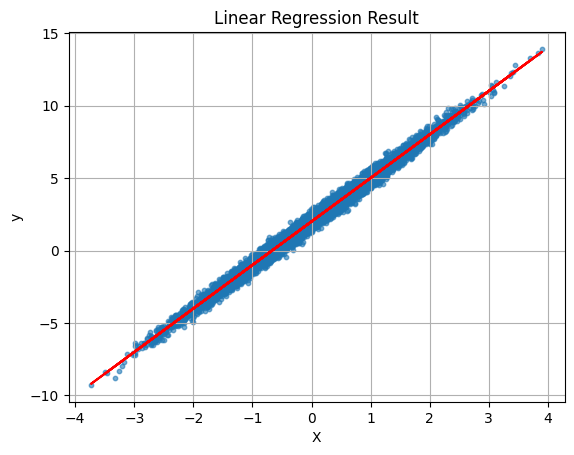

In [ ]:
plt.figure()
plt.scatter(X.numpy(), y.numpy(), s=10, alpha=0.6, label='Original Data')

# 학습된 회귀선 그리기
# no_grad() 블록 밖에서 w와 b를 사용해야 기울기 계산에 포함되지 않습니다.
predicted_y = X * w.item() + b.item() # .item()으로 스칼라 값 추출
plt.plot(X.numpy(), predicted_y.numpy(), color='red', label='Regression Line')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression Result')
plt.grid(True)
plt.show()